# Iterative Workflow: Number Guessing Game

The graph keeps guessing (binary search) until it finds the secret number.

```
START -> make_guess -> check_guess --(wrong)--> make_guess   (loop back)
                                   --(correct)-> END
```

In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal

In [2]:
class GuessState(TypedDict):
    secret: int
    low: int
    high: int
    guess: int
    hint: str
    attempts: int

In [3]:
def make_guess(state: GuessState):
    guess = (state['low'] + state['high']) // 2
    print(f"Attempt {state['attempts'] + 1}: guessing {guess}")
    return {'guess': guess, 'attempts': state['attempts'] + 1}


def check_guess(state: GuessState):
    if state['guess'] < state['secret']:
        return {'hint': 'higher', 'low': state['guess'] + 1}
    elif state['guess'] > state['secret']:
        return {'hint': 'lower', 'high': state['guess'] - 1}
    else:
        return {'hint': 'correct'}

In [4]:
# The loop: route BACK to make_guess until the guess is correct
def should_continue(state: GuessState) -> Literal['make_guess', '__end__']:
    if state['hint'] == 'correct':
        return END
    return 'make_guess'

In [5]:
graph = StateGraph(GuessState)

graph.add_node('make_guess', make_guess)
graph.add_node('check_guess', check_guess)

graph.add_edge(START, 'make_guess')
graph.add_edge('make_guess', 'check_guess')
graph.add_conditional_edges('check_guess', should_continue)

workflow = graph.compile()

In [6]:
result = workflow.invoke({'secret': 73, 'low': 1, 'high': 100, 'attempts': 0})
print(f"Found {result['guess']} in {result['attempts']} attempts")

Attempt 1: guessing 50
Attempt 2: guessing 75
Attempt 3: guessing 62
Attempt 4: guessing 68
Attempt 5: guessing 71
Attempt 6: guessing 73
Found 73 in 6 attempts


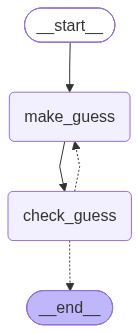

In [7]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())